# Analisis Dataset Opini SHS V1

Notebook ini menampilkan ringkasan dan visualisasi dataset `datasets/v1_shs_datasets.csv`.


In [1]:
from collections import Counter
from pathlib import Path
import csv
import sys

import matplotlib.pyplot as plt
import polars as pl


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "config.py").exists() and (candidate / "datasets").is_dir():
            return candidate
    return current


try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

ROOT = find_project_root(NOTEBOOK_DIR)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import config

DATASET_PATH = config.DATASETS / "raw_candidate_schema.csv"
FIGURE_DIR = config.FIGURES / "v1_shs_dataset_distribution"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(DATASET_PATH)

E:\School\tugas-akhir\project\datasets\raw_candidate_schema.csv


## 1. Load Data


In [2]:
with DATASET_PATH.open(newline="", encoding="utf-8-sig") as file:
    reader = csv.DictReader(file)
    rows = [dict(row) for row in reader]
    columns = list(reader.fieldnames or [])

for row in rows:
    for column in columns:
        value = row.get(column, "")
        row[column] = value.strip() if isinstance(value, str) else value

df = pl.DataFrame(rows)

print(f"Jumlah baris: {df.height}")
print(f"Jumlah kolom: {df.width}")
print(df.columns)
with pl.Config(tbl_rows=10, tbl_cols=-1, fmt_str_lengths=120):
    display(df)


Jumlah baris: 855
Jumlah kolom: 26
['text_id', 'text', 'subjectivity_type', 'speaker_type', 'public_opinion_scope', 'corpus_role', 'aspect', 'location', 'sentiment_label', 'label_status', 'source_id', 'source_type', 'source_url', 'dataset_tier', 'inclusion_status', 'verification_status', 'evidence_support_score', 'parent_text_id', 'decision_note', 'raw_source_file', 'raw_domain', 'content_status', 'query_group', 'query', 'raw_title', 'raw_text_length']


text_id,text,subjectivity_type,speaker_type,public_opinion_scope,corpus_role,aspect,location,sentiment_label,label_status,source_id,source_type,source_url,dataset_tier,inclusion_status,verification_status,evidence_support_score,parent_text_id,decision_note,raw_source_file,raw_domain,content_status,query_group,query,raw_title,raw_text_length
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""RAW-0001""","""Program Listrik Desa di Papua Hadirkan Terang dan Harapan Hingga Pelosok Negeri Program Listrik Desa di Papua Hadirkan T…","""public_expectation""","""community_representative""","""public_opinion""","""core_public_opinion""","""experience""","""Singkawang""","""""","""unlabeled""","""RAW-SRC-0001""","""online_news""","""https://www.suarapemredkalbar.com/read/nasional/26062026/program-listrik-desa-di-papua-hadirkan-terang-dan-harapan-hingg…","""A_candidate_core""","""candidate_analysis_ready""","""perlu_verifikasi""","""1.0""","""""","""candidate_from_raw_discovery""","""dataset_20260627T094855Z.json""","""www.suarapemredkalbar.com""","""success""","""issue:benefit""","""""elektrifikasi"" ""penerangan desa"" ""Melawi"" after:2024-01-01 before:2026-06-27""","""Program Listrik Desa di Papua Hadirkan Terang dan Harapan ...""","""5956"""
"""RAW-0002""","""Ari Yunianto on Instagram: ""Bekasi beres. Semangat…!! Antrian project installasi PLTS masih full sampai Agustus #plts #p…","""public_experience""","""community_representative""","""public_opinion""","""core_public_opinion""","""general_shs""","""Sambas""","""""","""unlabeled""","""RAW-SRC-0002""","""online_news""","""https://www.instagram.com/reel/DaCiaOBxC_d""","""A_candidate_core""","""candidate_analysis_ready""","""perlu_verifikasi""","""1.0""","""""","""candidate_from_raw_discovery""","""dataset_20260627T094855Z.json""","""www.instagram.com""","""success""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik"" ""Sambas"" after:2024-01-01 before:2026-06-27""","""Bekasi beres. Semangat…!! Antrian project installasi PLTS ...""","""455"""
"""RAW-0003""","""OIS POWER on Instagram: ""#PLTS #PanelSurya #SolarPanel #EnergiTerbarukan #SolarEnergy"" OIS POWER | #PLTS #PanelSurya #So…","""public_experience""","""community_representative""","""public_opinion""","""core_public_opinion""","""general_shs""","""Sambas""","""""","""unlabeled""","""RAW-SRC-0003""","""online_news""","""https://www.instagram.com/reel/DY0bixATBPD""","""A_candidate_core""","""candidate_analysis_ready""","""perlu_verifikasi""","""1.0""","""""","""candidate_from_raw_discovery""","""dataset_20260627T094855Z.json""","""www.instagram.com""","""success""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik"" ""Sambas"" after:2024-01-01 before:2026-06-27""","""OIS POWER | #PLTS #PanelSurya #SolarPanel ...""","""371"""
"""RAW-0004""","""TEKNIK LISTRIK on Instagram: ""Panel Surya Listrik (Fotovoltaik/PV) adalah teknologi yang mengambil energi dari cahaya ma…","""public_experience""","""community_representative""","""public_opinion""","""core_public_opinion""","""general_shs""","""Sambas""","""""","""unlabeled""","""RAW-SRC-0004""","""online_news""","""https://www.instagram.com/p/DRq794LgAB2""","""A_candidate_core""","""candidate_analysis_ready""","""perlu_verifikasi""","""1.0""","""""","""candidate_from_raw_discovery""","""dataset_20260627T094855Z.json""","""www.instagram.com""","""success""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik"" ""Sambas"" after:2024-01-01 before:2026-06-27""","""Panel Surya Listrik (Fotovoltaik/PV) adalah teknologi yang ...""","""792"""
"""RAW-0005""","""Datascrip Service Center on Instagram: ""Waktu yg tepat untuk membersihkan panel surya."" Waktu yg tepat untuk membersihka…","""public_experience""","""community_representative""","""public_opinion""","""core_public_opinion""","""general_shs""","""Sambas""","""""","""unlabeled""","""RAW-SRC-0005""","""online_news""","""https://www.instagram.com/reel/DQlfNxOATsq""","""A_

## 2. Ringkasan Kolom


In [3]:
summary_rows = []
for column in columns:
    values = [row.get(column, "") for row in rows]
    filled_count = sum(1 for value in values if value)
    unique_count = len({value for value in values if value})
    summary_rows.append({
        "column": column,
        "filled_count": filled_count,
        "empty_count": len(rows) - filled_count,
        "unique_count": unique_count,
        "filled_pct": round((filled_count / len(rows)) * 100, 2) if rows else 0,
    })

summary_df = pl.DataFrame(summary_rows)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(summary_df)


column,filled_count,empty_count,unique_count,filled_pct
str,i64,i64,i64,f64
"""text_id""",855,0,855,100.0
"""text""",855,0,854,100.0
"""subjectivity_type""",855,0,5,100.0
"""speaker_type""",855,0,3,100.0
"""public_opinion_scope""",855,0,4,100.0
"""corpus_role""",855,0,2,100.0
"""aspect""",855,0,11,100.0
"""location""",712,143,15,83.27
"""sentiment_label""",0,855,0,0.0


## 3. Fungsi Visualisasi


In [4]:
BAR_COLOR = "#2f6f9f"
GREEN_COLOR = "#3f7d20"
ORANGE_COLOR = "#8a5a00"


def clean_value(value):
    return value if value else "(kosong)"


def value_counts(column, top=None):
    counts = Counter(clean_value(row.get(column, "")) for row in rows)
    return dict(counts.most_common(top))


def safe_filename(name):
    return "".join(char if char.isalnum() or char in "-_" else "_" for char in name).strip("_")


def plot_bar(column, title=None, top=None, figsize=(9, 4), color=BAR_COLOR):
    data = value_counts(column, top=top)
    labels = list(data.keys())
    values = list(data.values())

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(labels, values, color=color)
    ax.set_title(title or column)
    ax.set_ylabel("Jumlah")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{safe_filename(column)}.png", dpi=160)
    plt.show()


def plot_horizontal_bar(column, title=None, top=10, figsize=(9, 5), color=BAR_COLOR):
    data = value_counts(column, top=top)
    labels = list(data.keys())[::-1]
    values = list(data.values())[::-1]

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(labels, values, color=color)
    ax.set_title(title or column)
    ax.set_xlabel("Jumlah")
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{safe_filename(column)}_top{top}.png", dpi=160)
    plt.show()


## 4. Sebaran Scope, Role, dan Tier Dataset


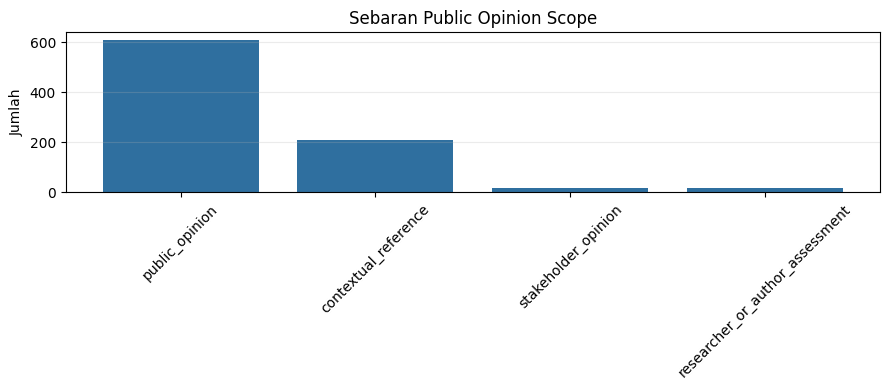

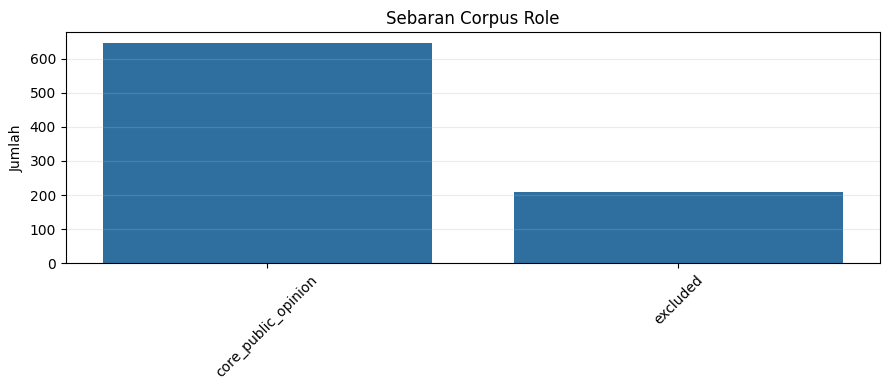

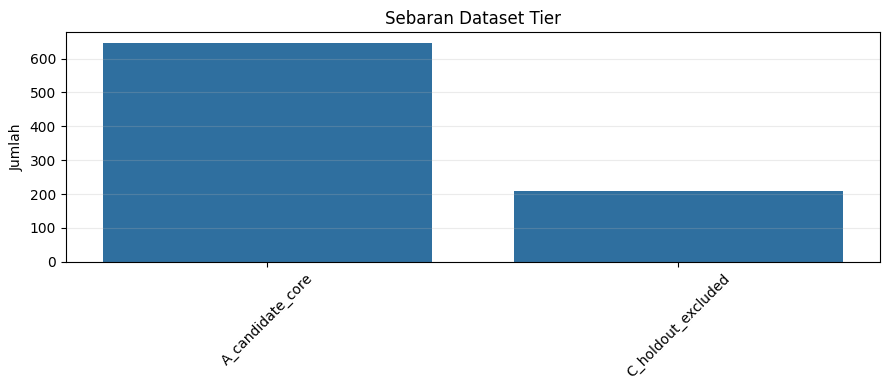

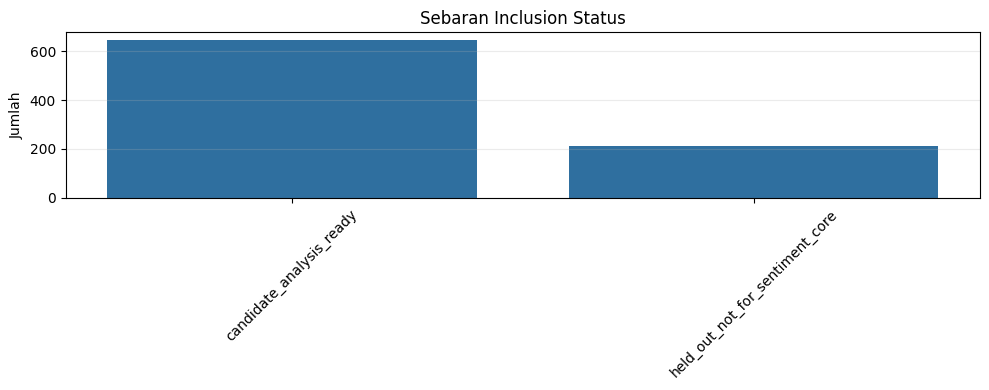

In [5]:
plot_bar("public_opinion_scope", "Sebaran Public Opinion Scope")
plot_bar("corpus_role", "Sebaran Corpus Role")
plot_bar("dataset_tier", "Sebaran Dataset Tier")
plot_bar("inclusion_status", "Sebaran Inclusion Status", figsize=(10, 4))


## 5. Sebaran Status Label dan Verifikasi


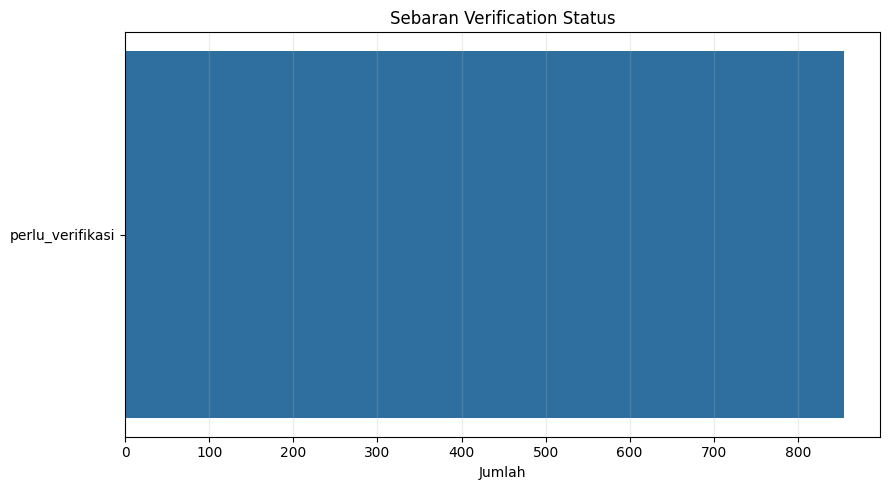

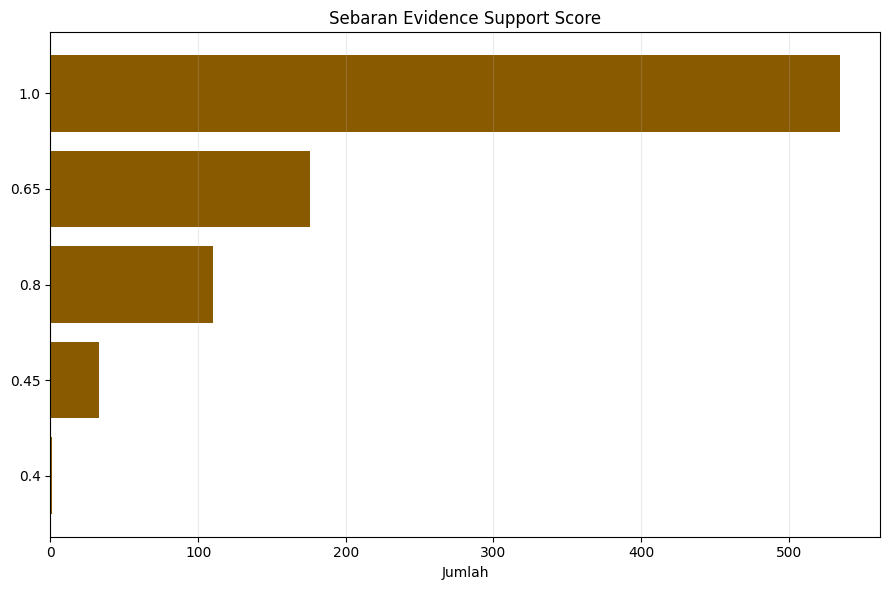

In [6]:
plot_horizontal_bar("verification_status", "Sebaran Verification Status", top=10, figsize=(9, 5))
plot_horizontal_bar("evidence_support_score", "Sebaran Evidence Support Score", top=12, figsize=(9, 6), color=ORANGE_COLOR)


## 6. Sebaran Pembicara dan Subjektivitas


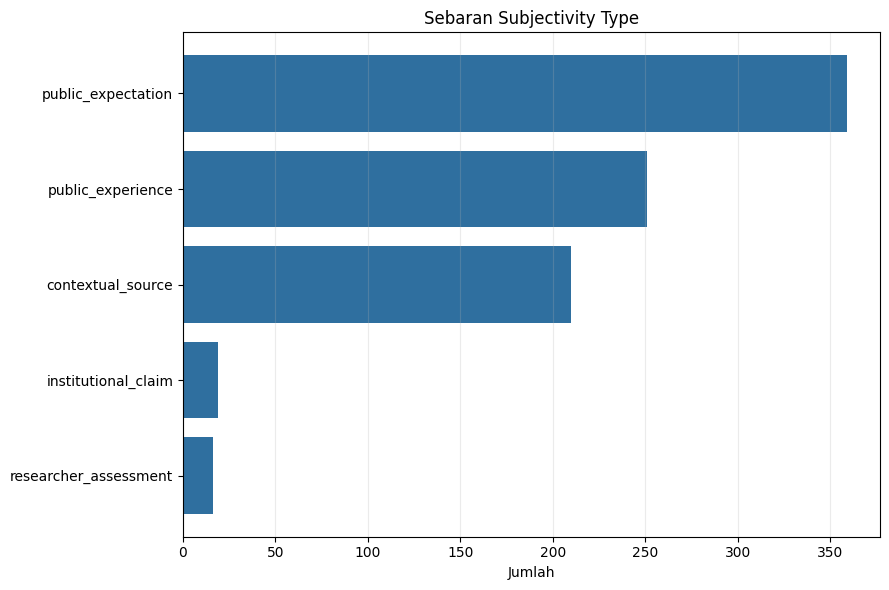

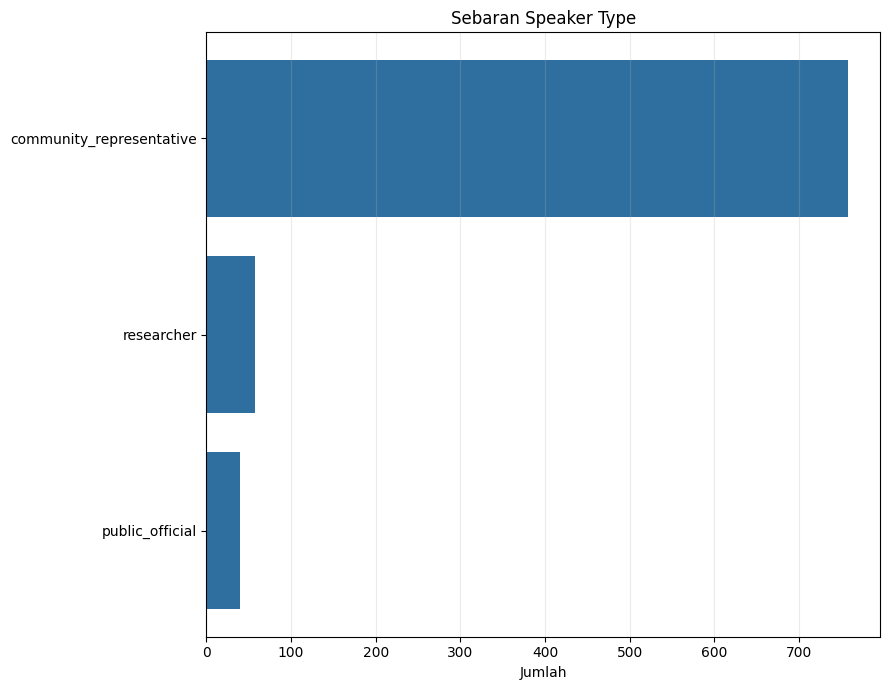

In [7]:
plot_horizontal_bar("subjectivity_type", "Sebaran Subjectivity Type", top=12, figsize=(9, 6))
plot_horizontal_bar("speaker_type", "Sebaran Speaker Type", top=15, figsize=(9, 7))


## 7. Sebaran Sumber dan Lokasi


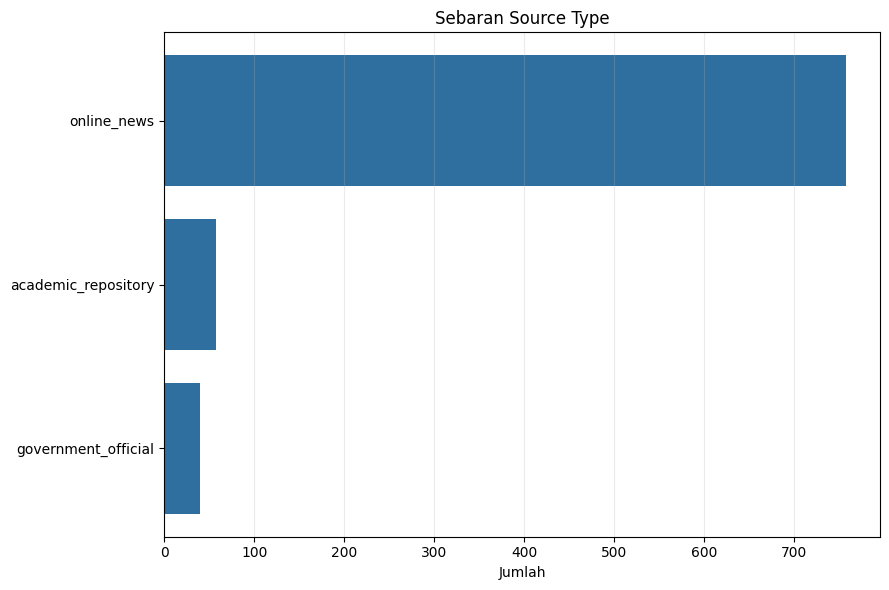

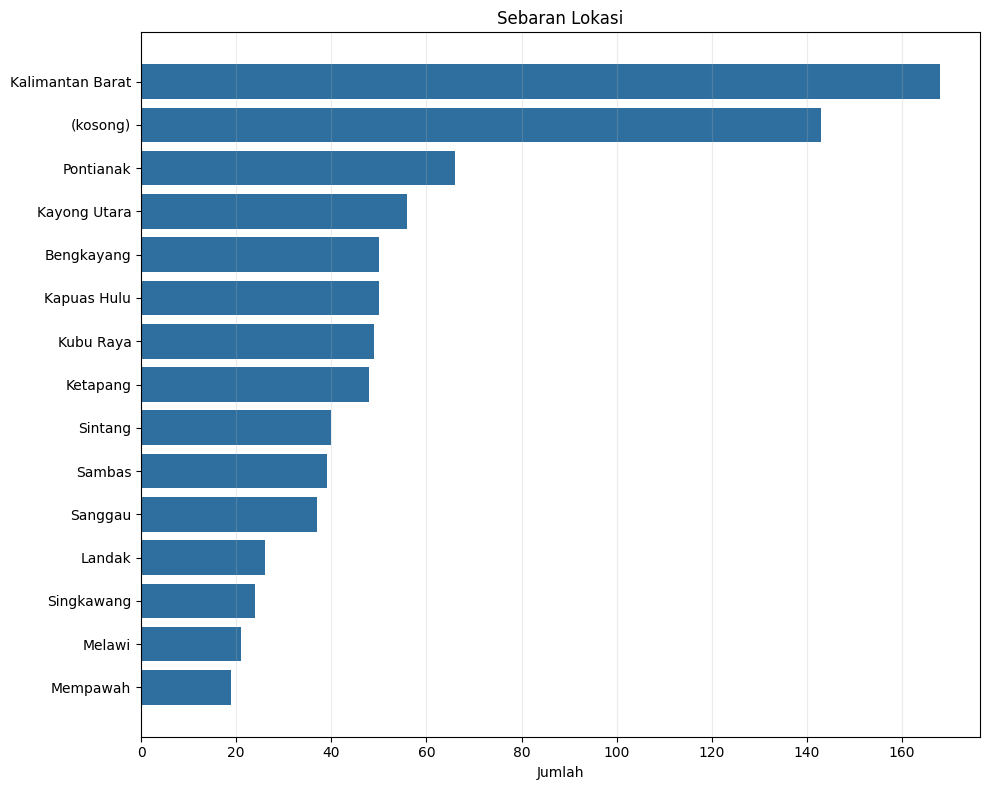

In [8]:
plot_horizontal_bar("source_type", "Sebaran Source Type", top=12, figsize=(9, 6))
plot_horizontal_bar("location", "Sebaran Lokasi", top=15, figsize=(10, 8))


## 8. Sebaran Aspek


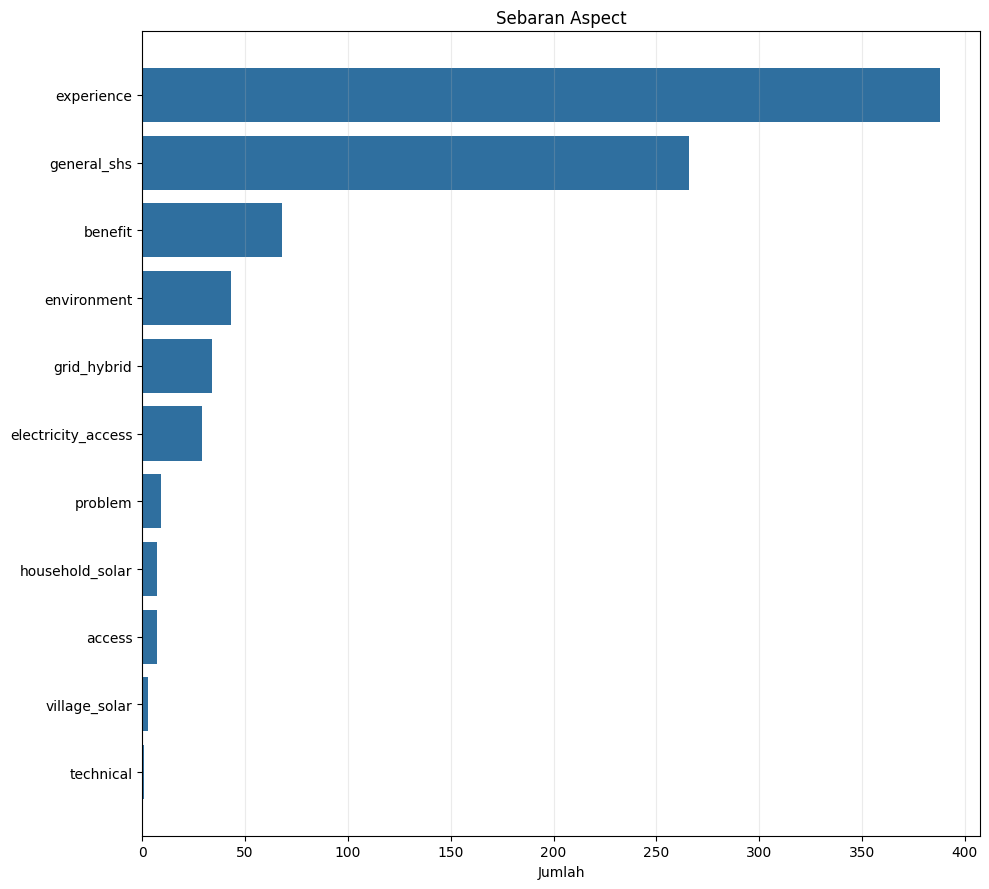

In [9]:
plot_horizontal_bar("aspect", "Sebaran Aspect", top=20, figsize=(10, 9))


## 9. Kelengkapan Kolom


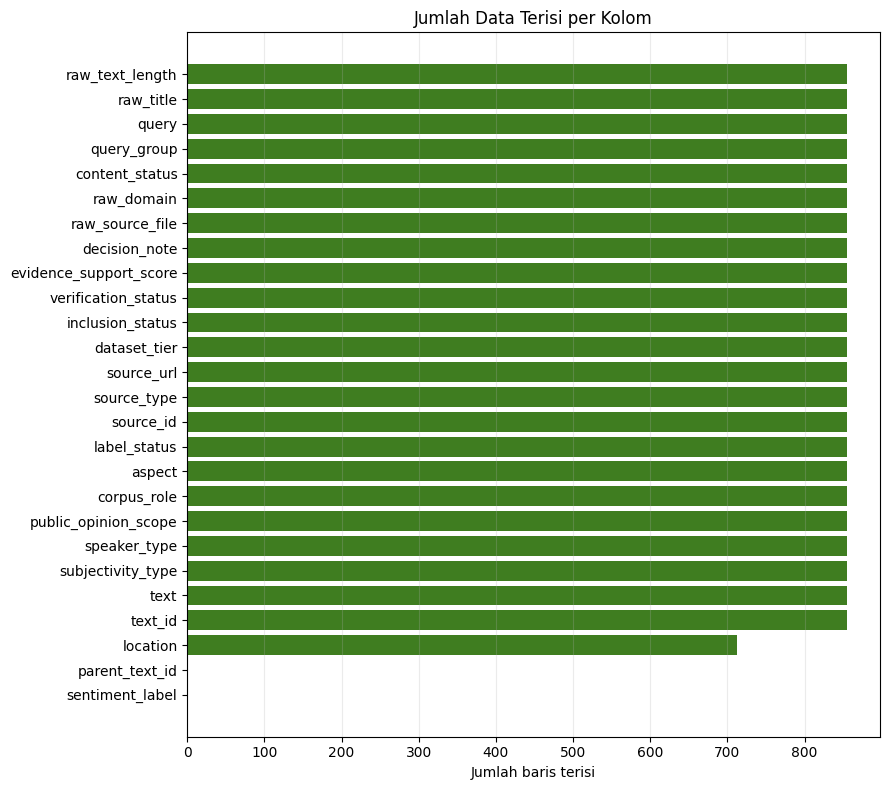

In [10]:
filled_counts = {column: sum(1 for row in rows if row.get(column, "")) for column in columns}
items = sorted(filled_counts.items(), key=lambda item: item[1])
labels = [item[0] for item in items]
values = [item[1] for item in items]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(labels, values, color=GREEN_COLOR)
ax.set_title("Jumlah Data Terisi per Kolom")
ax.set_xlabel("Jumlah baris terisi")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "filled_columns.png", dpi=160)
plt.show()


## 10. Contoh Teks per Tier


In [11]:
sample_columns = [
    "text_id",
    "dataset_tier",
    "inclusion_status",
    "public_opinion_scope",
    "subjectivity_type",
    "speaker_type",
    "aspect",
    "text",
]

sample_df = df.select(sample_columns).sort(["dataset_tier", "text_id"])
with pl.Config(tbl_rows=15, tbl_cols=-1, fmt_str_lengths=120):
    display(sample_df)


text_id,dataset_tier,inclusion_status,public_opinion_scope,subjectivity_type,speaker_type,aspect,text
str,str,str,str,str,str,str,str
"""RAW-0001""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_expectation""","""community_representative""","""experience""","""Program Listrik Desa di Papua Hadirkan Terang dan Harapan Hingga Pelosok Negeri Program Listrik Desa di Papua Hadirkan T…"
"""RAW-0002""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_experience""","""community_representative""","""general_shs""","""Ari Yunianto on Instagram: ""Bekasi beres. Semangat…!! Antrian project installasi PLTS masih full sampai Agustus #plts #p…"
"""RAW-0003""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_experience""","""community_representative""","""general_shs""","""OIS POWER on Instagram: ""#PLTS #PanelSurya #SolarPanel #EnergiTerbarukan #SolarEnergy"" OIS POWER | #PLTS #PanelSurya #So…"
"""RAW-0004""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_experience""","""community_representative""","""general_shs""","""TEKNIK LISTRIK on Instagram: ""Panel Surya Listrik (Fotovoltaik/PV) adalah teknologi yang mengambil energi dari cahaya ma…"
"""RAW-0005""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_experience""","""community_representative""","""general_shs""","""Datascrip Service Center on Instagram: ""Waktu yg tepat untuk membersihkan panel surya."" Waktu yg tepat untuk membersihka…"
"""RAW-0007""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_expectation""","""community_representative""","""general_shs""","""Damai Cable Indonesia on Instagram: ""Butuh kabel panel surya? Kami siap penuhi kebutuhan proyek energi terbarukanmu! Kua…"
"""RAW-0009""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_expectation""","""community_representative""","""experience""","""Wujud Negara Hadir, Pemerintah dan PLN Berhasil Listriki 99,92 Persen Desa di Seluruh Indonesia Wujud Negara Hadir, Peme…"
"""RAW-0010""","""A_candidate_core""","""candidate_analysis_ready""","""public_opinion""","""public_expectation""","""community_representative""","""experience""","""Warga Pulau Lemukutan Harapkan Listrik 24 Jam untuk Dongkrak Pariwisata Warga Pulau Lemukutan Harapkan Listrik 24 Jam un…"
…,…,…,…,…,…,…,…
